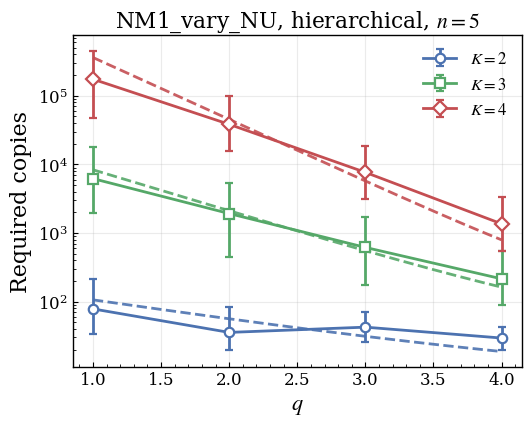

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


CSV_PATH = "existing_npz_postprocess_outputs/total_copy_complexity_summary.csv"



CASE = "NM1_vary_NU"

# LOWER_MODE = "exact"
LOWER_MODE = "hierarchical"

n = 5
depth_r = 5
epsilon = 0.1
K_list = [2, 3, 4]
Y_COLUMN = "geom_mean_total_copy_cost"

FIT_Q_VALUES = [1, 2, 3, 4]
PLOT_Q5_DATA = False
LINE_Q_VALUES = np.linspace(1, 4, 300)

CASE_TO_NM = {"NM1_vary_NU": 1, "NM100_vary_NU": 100}

N_U_GRID_MIN = 10
FLOOR_REL_TOL = 0.03
EXCLUDE_FLOOR_SATURATED_FROM_FIT = False
USE_GRID_FLOOR = False
FIT_IN_LOG_SCALE = True
ANCHOR_Q = None

beta0 = {2: 0.0, 3: 0.0, 4: 0.0} 
alpha = {2: 1.0, 3: 1.0, 4: 1.0}
# set beta0 to 0 for cleaner fitting, since we already have epsilon^2 on the denominator. 
# Setting beta0 to 0 also makes the fit more stable and less likely to encounter issues with negative remaining epsilon during fitting. 
# The alpha parameter will control how quickly beta decays with depth, and we can keep it at 1.0 for a reasonable decay rate.


COLORS = {2: "#4C72B0", 3: "#55A868", 4: "#C44E52"}
MARKERS = {2: "o", 3: "s", 4: "D"}

def set_style():
    plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "stix", "font.size": 13, "axes.labelsize": 16, "legend.fontsize": 9, "xtick.labelsize": 12, "ytick.labelsize": 12, "axes.linewidth": 1.0, "xtick.direction": "in", "ytick.direction": "in", "xtick.minor.visible": True, "ytick.minor.visible": True, "pdf.fonttype": 42, "ps.fonttype": 42})

def copy_factor(K, lower_mode):
    """
    Factor dealing with number of state copies
    """
    K = int(K)
    if lower_mode == "exact": return float(K)
    if lower_mode == "hierarchical": return float(K * (K + 1) / 2 - 1 * (K-1)**2)
    # if lower_mode == "hierarchical": return float(K**4)
    raise ValueError("lower_mode must be exact or hierarchical.")

def beta_depth(K, r):
    """
    Factor related to brickwork circuit depth.
    """
    return float(beta0[int(K)]) * np.exp(-float(alpha[int(K)]) * float(r))

def x_scaling(q, K):
    """
    Factor of (d/m)^{K-1}
    """
    q = np.asarray(q, dtype=float)
    return 2.0 ** ((n - q) * (int(K) - 1))

def grid_floor(K, lower_mode, N_M):
    return copy_factor(K, lower_mode) * float(N_U_GRID_MIN) * float(N_M)


def raw_Ncopies_model(q, K, lower_mode, N_M, a_K, b_K, r):
    q = np.asarray(q, dtype=float)
    beta = beta_depth(K, r)
    remaining = epsilon - beta
    if remaining <= 0: return np.full_like(q, np.inf, dtype=float)
    F_K = copy_factor(K, lower_mode)
    # return F_K * a_K * (N_M + 2 * np.sqrt(float(N_M)) *2**((n-q)*(K-1)/2) + 2**((n-q)*(K-1))) / (remaining ** 2)
    return F_K * a_K * (N_M  + 2**((n-q)*(K-1))) / (remaining ** 2)

def apply_grid_floor(y, K, lower_mode, N_M):
    y = np.asarray(y, dtype=float)
    if not USE_GRID_FLOOR: return y
    return np.maximum(y, grid_floor(K, lower_mode, N_M))

def NU_from_Ncopies(N_copies, K, lower_mode, N_M):
    return np.asarray(N_copies, dtype=float) / (copy_factor(K, lower_mode) * N_M)

def floor_saturation_mask(q_data, y_data, K, lower_mode, N_M):
    q_data = np.asarray(q_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)
    floor_value = grid_floor(K, lower_mode, N_M)
    return (q_data < n) & (y_data <= floor_value * (1.0 + FLOOR_REL_TOL))

def fit_a_b_for_K(q_data, y_data, K, lower_mode, N_M, r):
    q_data = np.asarray(q_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    finite_mask = np.isfinite(q_data) & np.isfinite(y_data) & (y_data > 0)
    q_data, y_data = q_data[finite_mask], y_data[finite_mask]

    saturated = floor_saturation_mask(q_data, y_data, K, lower_mode, N_M)
    fit_mask = ~saturated if EXCLUDE_FLOOR_SATURATED_FROM_FIT else np.ones_like(y_data, dtype=bool)

    q_fit, y_fit = q_data[fit_mask], y_data[fit_mask]

    beta = beta_depth(K, r)
    remaining = epsilon - beta
    F_K = copy_factor(K, lower_mode)

    if remaining <= 0:
        raise ValueError(f"K={K}: beta={beta} is larger than epsilon={epsilon}.")

    if len(q_fit) == 0:
        return 1e-300, 1e-300, np.nan, "all_points_floor_saturated", q_fit, y_fit

    if len(q_fit) == 1:
        x0 = x_scaling(np.array([q_fit[0]]), K)[0]
        b_K = y_fit[0] * remaining ** 2 / (F_K * x0)
        return 1e-300, float(max(b_K, 1e-300)), 0.0, "one_point_fallback_b_only", q_fit, y_fit

    theta0 = np.log(np.array([1.0, 1.0]))

    def residual(theta):
        a_K, b_K = np.exp(theta[0]), np.exp(theta[1])

        pred = np.maximum(
            raw_Ncopies_model(q_fit, K, lower_mode, N_M, a_K, b_K, r),
            1e-300,
        )

        if FIT_IN_LOG_SCALE:
            return np.log(pred) - np.log(y_fit)

        return (pred - y_fit) / np.maximum(y_fit, 1.0)

    res = least_squares(
        residual,
        theta0,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=20000,
    )

    return (
        float(np.exp(res.x[0])),
        float(np.exp(res.x[1])),
        float(res.cost),
        "two_parameter_detailed_bound_fit",
        q_fit,
        y_fit,
    )

def anchor_raw_prediction(q_line, raw_y_line, q_data, y_data, K, lower_mode, N_M):
    if ANCHOR_Q is None: return raw_y_line, 1.0, "no_anchor"
    q_data, y_data = np.asarray(q_data, dtype=float), np.asarray(y_data, dtype=float)
    idx = np.where(np.isclose(q_data, float(ANCHOR_Q)))[0]
    if len(idx) == 0: return raw_y_line, 1.0, "anchor_q_not_found"
    y_anchor_data = y_data[idx[0]]
    saturated = floor_saturation_mask(np.array([ANCHOR_Q], dtype=float), np.array([y_anchor_data], dtype=float), K, lower_mode, N_M)[0]
    if saturated: return raw_y_line, 1.0, "anchor_q_floor_saturated_skipped"
    y_anchor_pred = np.interp(float(ANCHOR_Q), q_line, raw_y_line)
    if not np.isfinite(y_anchor_data) or not np.isfinite(y_anchor_pred) or y_anchor_pred <= 0: return raw_y_line, 1.0, "anchor_invalid"
    C = float(y_anchor_data / y_anchor_pred)
    return C * raw_y_line, C, "anchored"

def plot_one_panel():
    set_style()
    df = pd.read_csv(CSV_PATH)
    if Y_COLUMN not in df.columns: raise ValueError(f"Cannot find column '{Y_COLUMN}'. Available columns are:\n{list(df.columns)}")
    if "N_M" not in df.columns: df["N_M"] = df["case"].map(CASE_TO_NM)
    sub = df[(df["case"] == CASE) & (df["lower_mode"] == LOWER_MODE)].copy()
    if len(sub) == 0: raise ValueError(f"No data found for CASE={CASE}, LOWER_MODE={LOWER_MODE}")
    N_M = int(CASE_TO_NM[CASE])
    fig, ax = plt.subplots(figsize=(5.8, 4.3))
    fit_rows, pred_rows, diagnostics_rows = [], [], []

    dominant_factor = {2: 4.0, 3: 7.0, 4: 11.0}

    for K in K_list:
        ss = sub[sub["K"] == K].sort_values("q").copy()
        if len(ss) == 0: continue
        q_all, y_all = ss["q"].to_numpy(float), ss[Y_COLUMN].to_numpy(float)
        q_plot, y_plot = (q_all, y_all) if PLOT_Q5_DATA else (q_all[q_all < n], y_all[q_all < n])



        # ax.plot(q_plot, y_plot, linestyle="None", marker=MARKERS[K], ms=6.8, mfc="white", mew=1.6, color=COLORS[K], label=rf"$K={K}$ data")
        y = ss[Y_COLUMN].to_numpy(float)
        ylo = ss["q16_total_copy_cost"].to_numpy(float)
        yhi = ss["q84_total_copy_cost"].to_numpy(float)
        mask = (q_all < n) if not PLOT_Q5_DATA else np.ones(len(q_all), dtype=bool)
        ax.errorbar(
            q_all[mask], y[mask],
            yerr=np.abs(np.vstack([y[mask] - ylo[mask], yhi[mask] - y[mask]])),
            marker=MARKERS[K],
            lw=2,
            ms=6.8,
            mfc="white",
            mew=1.6,
            capsize=3,
            color=COLORS[K],
            label=rf"$K={K}$",
        )




        fit_mask_basic = ss["q"].isin(FIT_Q_VALUES).to_numpy() & np.isfinite(y_all) & (y_all > 0)
        q_fit_candidate, y_fit_candidate = q_all[fit_mask_basic], y_all[fit_mask_basic]
        sat_mask = floor_saturation_mask(q_fit_candidate, y_fit_candidate, K, LOWER_MODE, N_M)
        for qq, yy, sat in zip(q_fit_candidate, y_fit_candidate, sat_mask):
            diagnostics_rows.append({"case": CASE, "lower_mode": LOWER_MODE, "K": K, "q": int(qq), "y_geom": yy, "floor": grid_floor(K, LOWER_MODE, N_M), "floor_saturated": bool(sat)})
        a_K, b_K, fit_cost, fit_status, q_used, y_used = fit_a_b_for_K(q_fit_candidate, y_fit_candidate, K, LOWER_MODE, N_M, depth_r)
        raw_y_line = raw_Ncopies_model(LINE_Q_VALUES, K, LOWER_MODE, N_M, a_K, b_K, depth_r)
        raw_y_line, anchor_C, anchor_status = anchor_raw_prediction(LINE_Q_VALUES, raw_y_line, q_all, y_all, K, LOWER_MODE, N_M)
        y_line = apply_grid_floor(raw_y_line, K, LOWER_MODE, N_M)
        ax.plot(LINE_Q_VALUES, y_line, "--", lw=2.0, color=COLORS[K], alpha=0.9)
        beta, F_K = beta_depth(K, depth_r), copy_factor(K, LOWER_MODE)
        fit_rows.append({"case": CASE, "lower_mode": LOWER_MODE, "K": K, "n": n, "depth_r": depth_r, "N_M": N_M, "epsilon": epsilon, "beta_depth": beta, "a_K_random_U_term": a_K, "b_K_measurement_postselection_term": b_K, "copy_factor_FK": F_K, "fit_cost": fit_cost, "fit_status": fit_status, "num_candidate_fit_points": len(q_fit_candidate), "num_used_fit_points": len(q_used), "q_used_for_fit": list(q_used), "use_grid_floor": USE_GRID_FLOOR, "N_U_grid_min": N_U_GRID_MIN, "floor": grid_floor(K, LOWER_MODE, N_M), "anchor_q": ANCHOR_Q, "anchor_C": anchor_C, "anchor_status": anchor_status, "y_column": Y_COLUMN, "fit_formula": "F_K*(N_M*a_K + 2*sqrt(N_M*a_K*b_K)*2^((n-q)(K-1)/2) + b_K*2^((n-q)(K-1)))/(epsilon-beta_K(r))^2"})
        for q_int in sorted(ss["q"].unique()):
            q_int = int(q_int)
            x_val = x_scaling(np.array([q_int]), K)[0]
            raw_pred = raw_Ncopies_model(np.array([q_int]), K, LOWER_MODE, N_M, a_K, b_K, depth_r)[0] * anchor_C
            pred = apply_grid_floor(np.array([raw_pred]), K, LOWER_MODE, N_M)[0]
            NU_pred = NU_from_Ncopies(pred, K, LOWER_MODE, N_M)
            pred_rows.append({"case": CASE, "lower_mode": LOWER_MODE, "K": K, "q": q_int, "n": n, "depth_r": depth_r, "N_M": N_M, "epsilon": epsilon, "beta_depth": beta, "x_scaling_2_power": x_val, "sqrt_x_scaling": np.sqrt(x_val), "raw_N_copies_pred": raw_pred, "floor_clipped_N_copies_pred": pred, "N_U_pred": NU_pred, "floor": grid_floor(K, LOWER_MODE, N_M), "a_K_random_U_term": a_K, "b_K_measurement_postselection_term": b_K, "anchor_C": anchor_C, "y_column": Y_COLUMN})


    ax.set_yscale("log")
    ax.set_xlabel(r"$q$")
    ax.set_ylabel("Required copies")
    ax.set_title(rf"{CASE}, {LOWER_MODE}, $n={n}$")
    ax.grid(True, which="major", alpha=0.25)
    ax.legend(frameon=False, fontsize=12)
    plt.show()

if __name__ == "__main__":
    plot_one_panel()